In [ ]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("obulisainaren/forest-fire-c4")

print("Path to dataset files:", path)

# The variable 'base_path' was not defined.
# Assuming 'base_path' was intended to be the parent directory of 'path'.
base_path = os.path.dirname(path)

print(f"Contents of base_path ({base_path}):\n{os.listdir(base_path)}")
print(f"Contents of path ({path}):\n{os.listdir(path)}")

100%|██████████| 123M/123M [00:00<00:00, 149MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/obulisainaren/forest-fire-c4/versions/2
Contents of base_path (/root/.cache/kagglehub/datasets/obulisainaren/forest-fire-c4/versions):
['2']
Contents of path (/root/.cache/kagglehub/datasets/obulisainaren/forest-fire-c4/versions/2):
['Forect Fire', 'README.md']


In [ ]:
import os

# Point to the 'Forect Fire' directory inside the dataset
data_path = os.path.join(path, 'Forect Fire')

# List forest fire class directories
if os.path.exists(data_path):
    classes = [d for d in os.listdir(data_path) if os.path.isdir(os.path.join(data_path, d))]
    print(f"Forest fire classes found: {classes}")
else:
    print(f"Path not found: {data_path}")

Forest fire classes found: ['Forest Fire_Tester', 'Forest Fire_Dataset']



--- Displaying Sample Images from Dataset (/root/.cache/kagglehub/datasets/obulisainaren/forest-fire-c4/versions/2/Forect Fire) ---
Found 4823 images. Displaying 6 sample images:


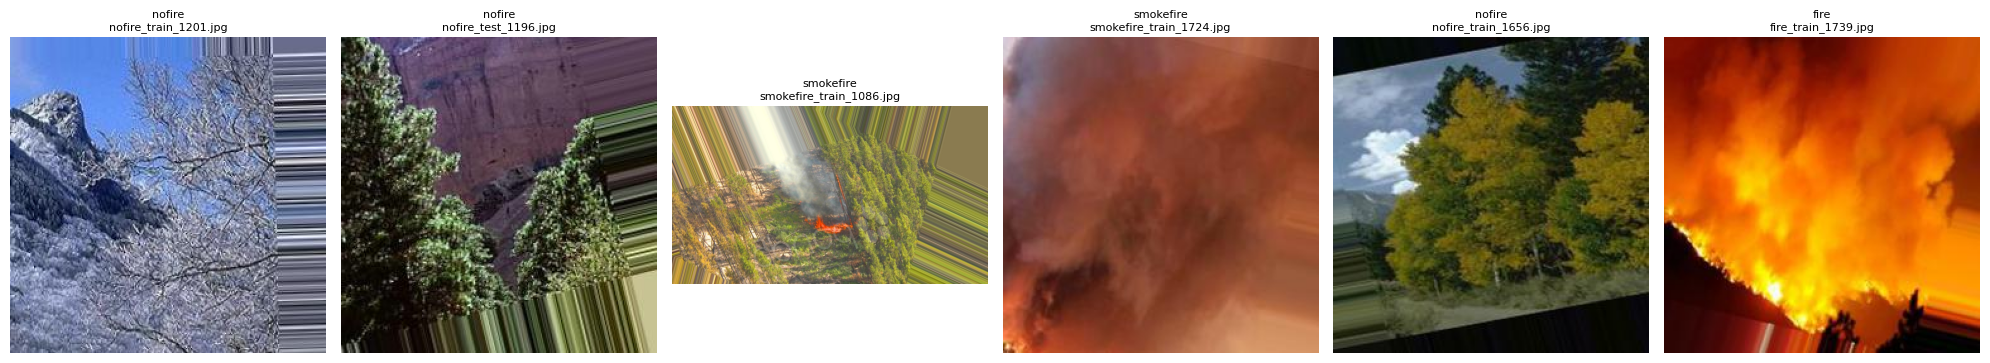

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import random
import os

def display_sample_images(dataset_path, num_samples=6):
    image_extensions = ('.png', '.jpg', '.jpeg', '.gif', '.bmp')
    all_image_paths = []

    for root, dirs, files in os.walk(dataset_path):
        for file in files:
            if file.lower().endswith(image_extensions):
                all_image_paths.append(os.path.join(root, file))

    if not all_image_paths:
        print(f"No images found in {dataset_path}.")
        return

    print(f"Found {len(all_image_paths)} images. Displaying {min(num_samples, len(all_image_paths))} sample images:")

    samples_to_display = random.sample(all_image_paths, min(len(all_image_paths), num_samples))

    fig, axes = plt.subplots(1, len(samples_to_display), figsize=(20, 5))
    if len(samples_to_display) == 1:
        axes = [axes]

    for i, img_path in enumerate(samples_to_display):
        try:
            img = Image.open(img_path)
            axes[i].imshow(img)
            # Get class name from parent directory name
            label = os.path.basename(os.path.dirname(img_path))
            axes[i].set_title(f"{label}\n{os.path.basename(img_path)}", fontsize=8)
            axes[i].axis('off')
        except Exception as e:
            print(f"Error loading {img_path}: {e}")

    plt.tight_layout()
    plt.show()

# Use the updated path pointing to the images folder
data_path = os.path.join(path, 'Forect Fire')
print(f"\n--- Displaying Sample Images from Dataset ({data_path}) ---")
display_sample_images(data_path)

In [ ]:
import tensorflow as tf

# Check for GPU availability
device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
  print('GPU device not found. Training will proceed on CPU (slower).')
else:
  print('Found GPU at: {}'.format(device_name))

print(f"TensorFlow Version: {tf.__version__}")

Found GPU at: /device:GPU:0
TensorFlow Version: 2.20.0


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2

# Configuration
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 10

# Data preprocessing and loading
dataset = tf.keras.utils.image_dataset_from_directory(
    data_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

# Split into train and validation sets (80/20)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_ds = dataset.take(train_size)
val_ds = dataset.skip(train_size)

# Build MobileNetV2 model
with tf.device('/GPU:0' if device_name == '/device:GPU:0' else '/CPU:0'):
    base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
    base_model.trainable = False  # Freeze base model

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(dataset.element_spec[1].shape[-1], activation='softmax')
    ])

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()

Found 4823 files belonging to 2 classes.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │         2,562 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,260,546 (8.62 MB)

 Trainable params: 2,562 (10.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
# Train the model
print("Starting Training...")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Starting Training...
Epoch 1/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 51s 254ms/step - accuracy: 0.9935 - loss: 0.0375 - val_accuracy: 0.9929 - val_loss: 0.0422
Epoch 2/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 14s 113ms/step - accuracy: 0.9956 - loss: 0.0216 - val_accuracy: 0.9939 - val_loss: 0.0389
Epoch 3/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 14s 115ms/step - accuracy: 0.9953 - loss: 0.0191 - val_accuracy: 0.9949 - val_loss: 0.0309
Epoch 4/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 18s 149ms/step - accuracy: 0.9956 - loss: 0.0140 - val_accuracy: 0.9939 - val_loss: 0.0396
Epoch 5/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 16s 135ms/step - accuracy: 0.9961 - loss: 0.0127 - val_accuracy: 0.9939 - val_loss: 0.0347
Epoch 6/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 17s 141ms/step - accuracy: 0.9964 - loss: 0.0109 - val_accuracy: 0.9939 - val_loss: 0.0337
Epoch 7/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 13s 112ms/step - accuracy: 0.9971 - loss: 0.0094 - val_accuracy: 0.9939 - val_loss: 0.0339
Epoch 8/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 14s 113ms/step - accur

In [ ]:
# Model Summary Results
loss, accuracy = model.evaluate(val_ds)
print(f"\n--- Training Summary ---")
print(f"Final Validation Loss: {loss:.4f}")
print(f"Final Validation Accuracy: {accuracy:.4f}")

31/31 ━━━━━━━━━━━━━━━━━━━━ 8s 86ms/step - accuracy: 0.9939 - loss: 0.0343

--- Training Summary ---
Final Validation Loss: 0.0343
Final Validation Accuracy: 0.9939


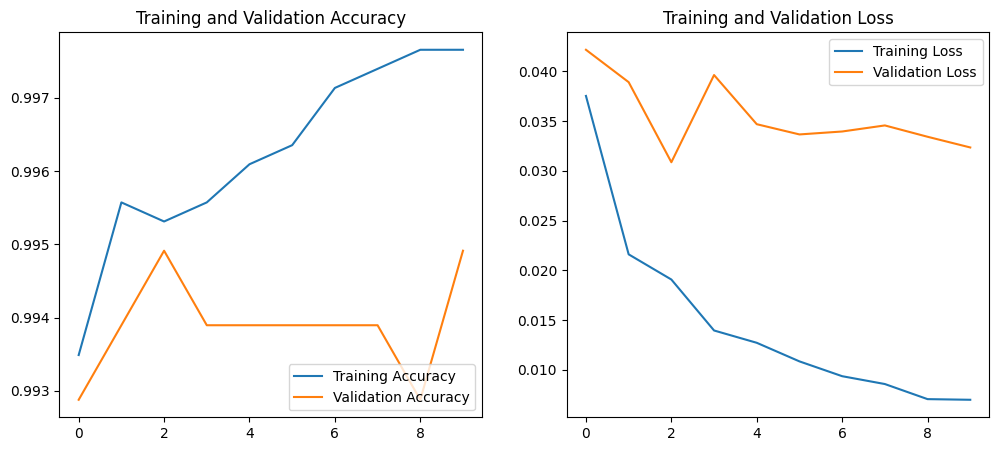

In [ ]:
import matplotlib.pyplot as plt

# Plot Training History
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(EPOCHS)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend(loc='lower right')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.legend(loc='upper right')
plt.show()